# Introduction to Machine Learning for Neuroscience
# Final Project
**05/03/2025** 

**Gilad Shilo ID: 318337136**

**Iakov Odesser ID: 209860288**

## EDA

We begin by loading the EmoSet dataset from JSON and flattening the nested annotations into a pandas DataFrame. 


In [67]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import wordcloud

In [68]:
file_path = 'emoset_challenge_1000_augmented.json'
with open(file_path, 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.json_normalize(data, sep='_')  # flatten nested annotations

print("--- Data Overview ---")
df.info()
print("\n--- First 5 Rows ---")
print(df.head())


--- Data Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_image_id           1000 non-null   object 
 7   annotations_emotion            1000 non-null   object 
 8   annotations_brightness         999 non-null    float64
 9   annotations_colorfulness       976 non-null    float64
 10  annotations_facial_expression  112 non-null    object 
 11  annotations_object             513 non-null    object 
 12  annotations_human_action   

It seems that image_name and annotations_image_id are the same. We'll make sure that they are indeeed 100% identical and drop the latter if the assumption holds 

In [69]:
df = df.drop(columns=['annotations_image_id']) if (df['image_name'].str.replace('.jpg', '', regex=False) == df['annotations_image_id']).all() else df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   image_name                     1000 non-null   object 
 1   description                    1000 non-null   object 
 2   embedding                      1000 non-null   object 
 3   viewer_feelings                1000 non-null   object 
 4   description_embedding          1000 non-null   object 
 5   viewer_feelings_embedding      1000 non-null   object 
 6   annotations_emotion            1000 non-null   object 
 7   annotations_brightness         999 non-null    float64
 8   annotations_colorfulness       976 non-null    float64
 9   annotations_facial_expression  112 non-null    object 
 10  annotations_object             513 non-null    object 
 11  annotations_human_action       114 non-null    object 
 12  annotations_scene              212 non-null    ob

We now proceed to explore the descriptives: 

In [70]:
print("\n--- Emotion Distribution ---")
emotion_counts = df['annotations_emotion'].value_counts()
print(emotion_counts)

print("\n--- Summary Statistics for Visual Features ---")
print(df[['annotations_brightness', 'annotations_colorfulness']].describe())



--- Emotion Distribution ---
annotations_emotion
anger          125
excitement     125
disgust        125
amusement      125
awe            125
contentment    125
sadness        125
fear           125
Name: count, dtype: int64

--- Summary Statistics for Visual Features ---
       annotations_brightness  annotations_colorfulness
count              999.000000                976.000000
mean                 0.483884                  0.493545
std                  0.151183                  0.195302
min                  0.000000                  0.000000
25%                  0.400000                  0.400000
50%                  0.500000                  0.500000
75%                  0.600000                  0.600000
max                  0.900000                  1.000000


Evidently, we have a uniform distribution. The columns of interest almost lack NaN values, and we'll handle them later on. We now proceed to plotting: 

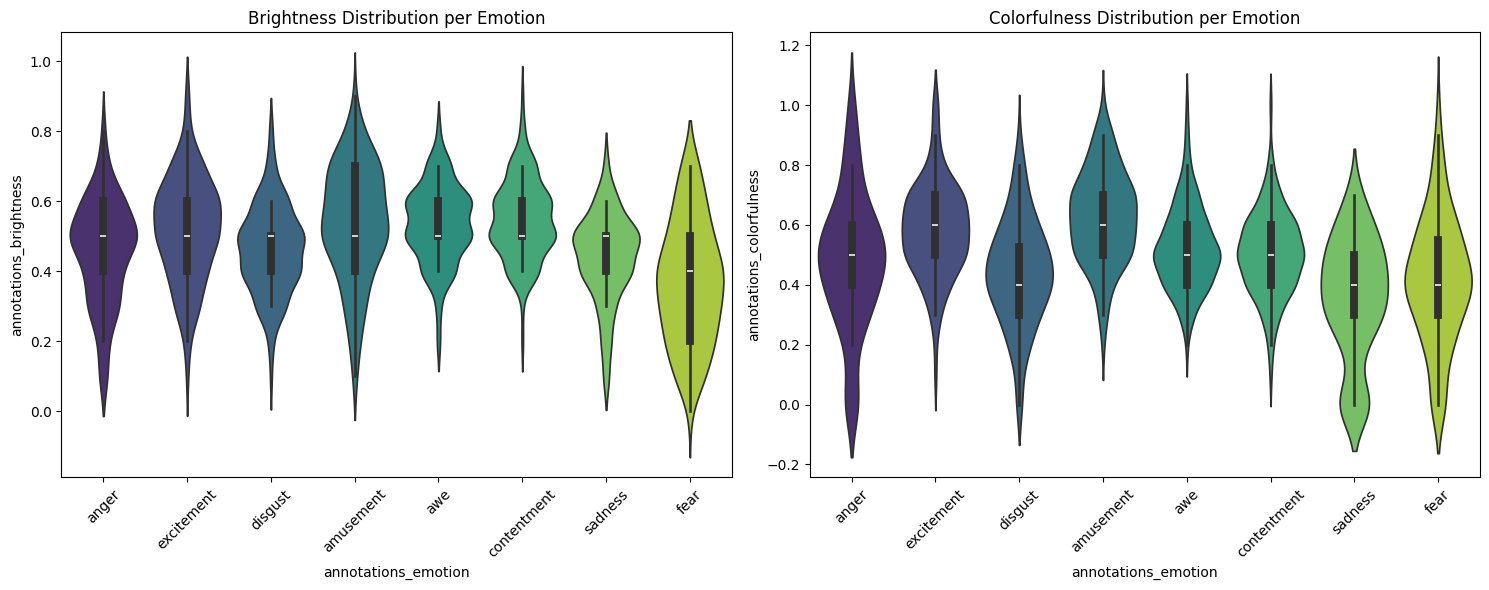

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))  # brightness & colorfulness per emotion
sns.violinplot(ax=axes[0], data=df, x='annotations_emotion', y='annotations_brightness', palette='viridis', hue='annotations_emotion', legend=False)

axes[0].set_title('Brightness Distribution per Emotion')
axes[0].tick_params(axis='x', rotation=45)

sns.violinplot(ax=axes[1], data=df, x='annotations_emotion', y='annotations_colorfulness', palette='viridis', hue='annotations_emotion', legend=False)
axes[1].set_title('Colorfulness Distribution per Emotion')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

From the violin plots, we can observe:

*Brightness:* Fear is associated with darker images, while amusement and excitement tend toward brighter imagery, suggesting a relationship between image brightness and emotional valence.

*Colorfulness:* Sadness and fear exhibit notably lower colorfulness compared to other emotions, while excitement and amusement show higher saturation, indicating that positive high-arousal emotions correlate with more vibrant imagery.

We also examine the distribution of description lengths to assess consistency in the GPT-generated captions.

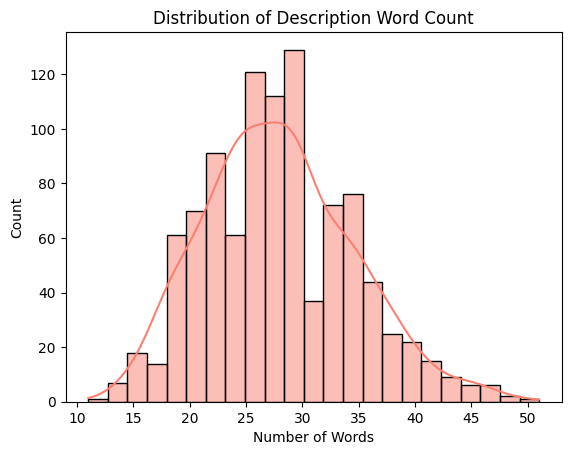

In [72]:
df['description_word_count'] = df['description'].str.split().str.len()

sns.histplot(df['description_word_count'], kde=True, color='salmon')
plt.title('Distribution of Description Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

### Embedding Alignment Analysis

We compute the cosine similarity between each image's GPT-generated description embedding and its viewer feelings embedding — both from `text-embedding-3-small`, making them directly comparable. High similarity would suggest that the objective visual description and the subjective emotional response it evokes are closely aligned.

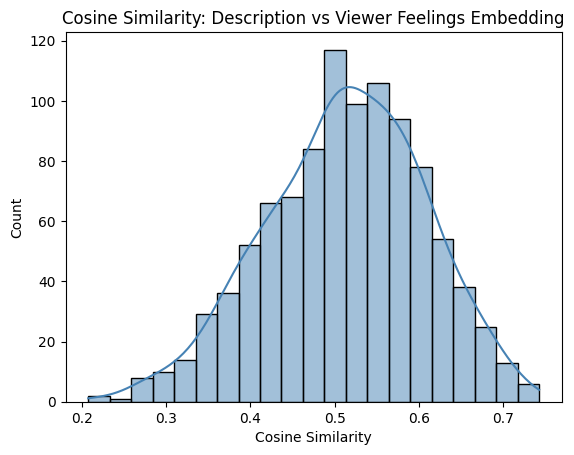

Mean similarity: 0.513
Std: 0.095


In [73]:
from sklearn.metrics.pairwise import cosine_similarity

desc_embeddings = np.array(df['description_embedding'].tolist())
feelings_embeddings = np.array(df['viewer_feelings_embedding'].tolist())

df['desc_feelings_cosine_sim'] = [cosine_similarity([d], [f])[0][0] 
                                   for d, f in zip(desc_embeddings, feelings_embeddings)]

sns.histplot(df['desc_feelings_cosine_sim'], kde=True, color='steelblue')
plt.title('Cosine Similarity: Description vs Viewer Feelings Embedding')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

print(f"Mean similarity: {df['desc_feelings_cosine_sim'].mean():.3f}")
print(f"Std: {df['desc_feelings_cosine_sim'].std():.3f}")

The mean cosine similarity of 0.51 between description and viewer feelings embeddings suggests moderate alignment — the objective visual content and the subjective emotional response it evokes share common semantic space, but are clearly not identical, which is expected given the gap between *what is seen* and *how it feels*.

### Viewer Feelings Word Cloud per Emotion

We visualize the most frequent words in the GPT-generated viewer feelings descriptions for each emotion category. This serves as a qualitative sanity check — if the word clouds are semantically coherent with their emotion label, it validates the quality of the generated text. Words that are very frequent across all emotions due to their natural being part of a description 

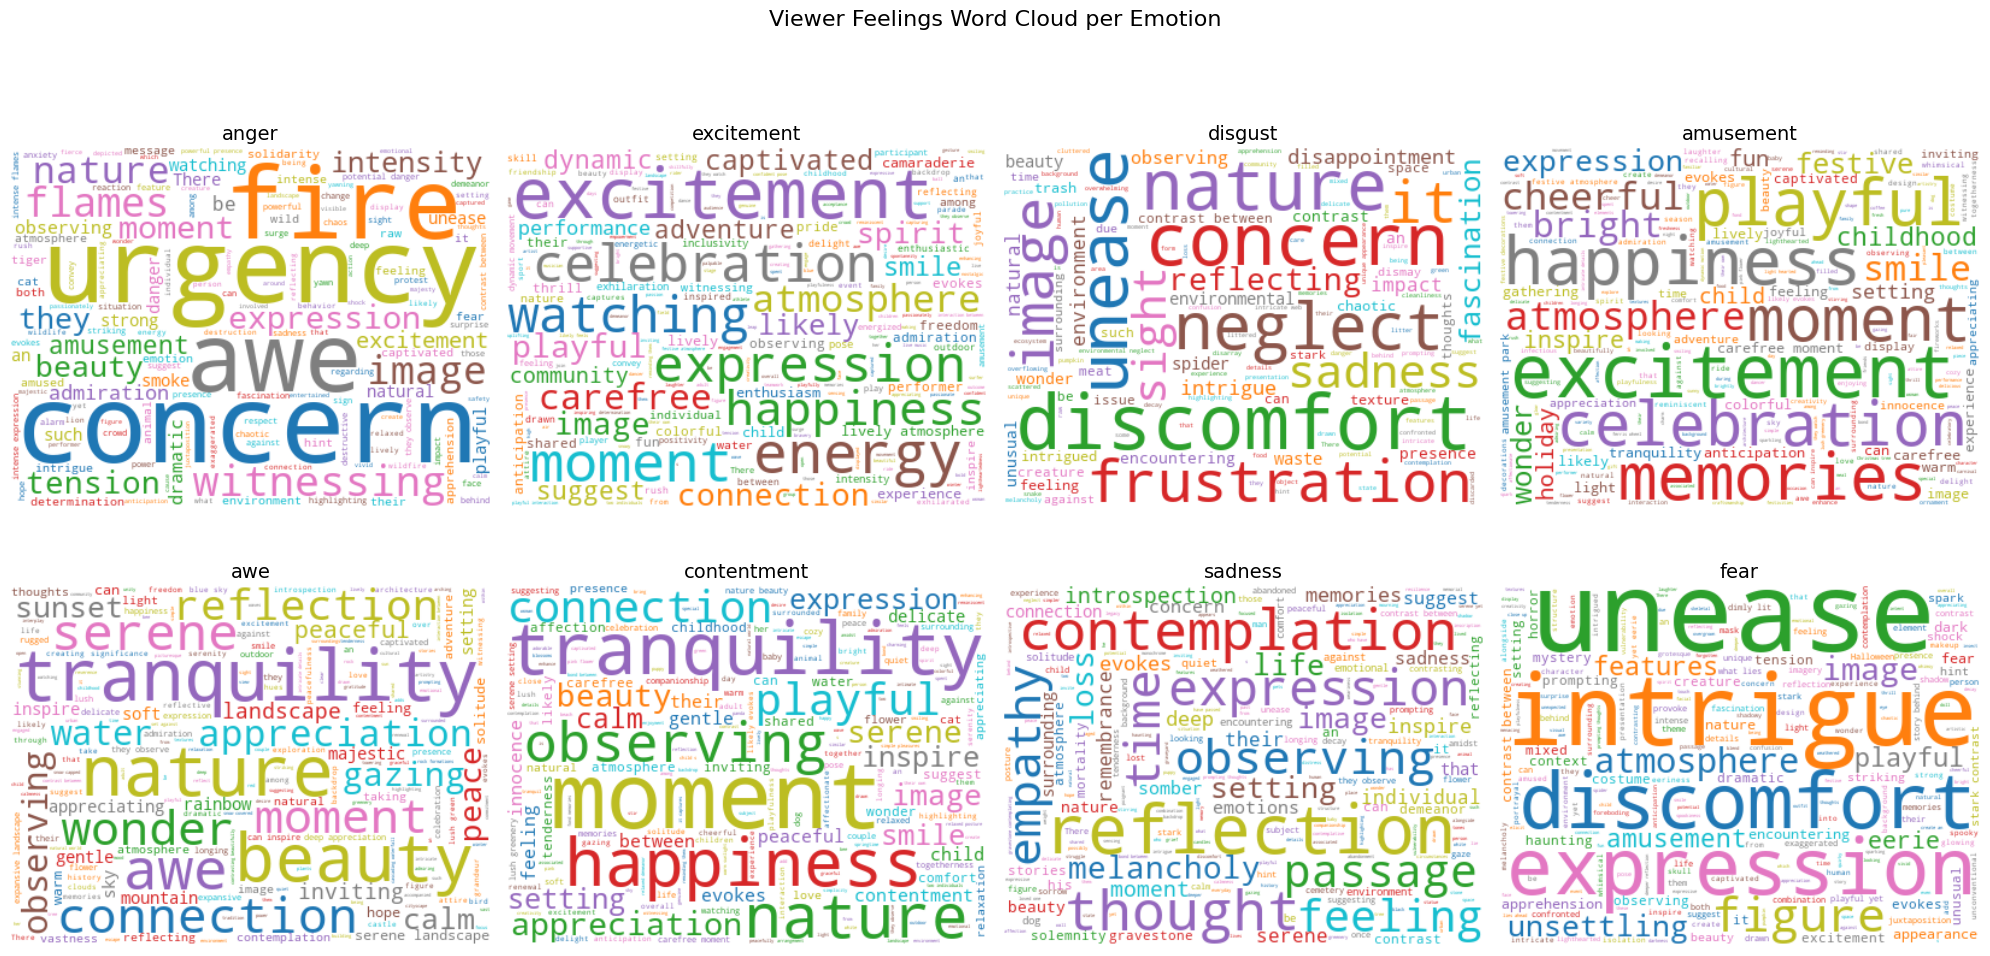

In [97]:
from wordcloud import WordCloud
from collections import Counter

# build global stopword list from words dominant across all emotions
all_text = ' '.join(df['viewer_feelings'].dropna().tolist())
global_freq = Counter(all_text.lower().split())
global_stopwords = {word for word, count in global_freq.items() if count > 140}
                    

emotions = df['annotations_emotion'].unique()
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for ax, emotion in zip(axes.flatten(), emotions):
    text = ' '.join(df[df['annotations_emotion'] == emotion]['viewer_feelings'].dropna().tolist())
    wc = WordCloud(width=400, height=300, background_color='white', colormap='tab10',
                   stopwords=global_stopwords).generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(emotion, fontsize=14)
    ax.axis('off')

plt.suptitle('Viewer Feelings Word Cloud per Emotion', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The word clouds, after filtering globally dominant GPT phrasing (threshold: >140 occurrences across the dataset), now surface clearly emotion-specific vocabulary — *anger* foregrounds "urgency", "fire" and "concern"; *fear* highlights "unease", "intrigue" and "discomfort"; *awe* centers on "tranquility", "serene" and "wonder"; and *contentment* surfaces "tranquility", "happiness" and "connection" — validating that the GPT-generated viewer feelings are semantically coherent with their emotion labels.

### Description Length per Emotion

We examine whether certain emotions are associated with longer or shorter GPT-generated descriptions, which may hint at the visual complexity of images evoking different emotional responses.

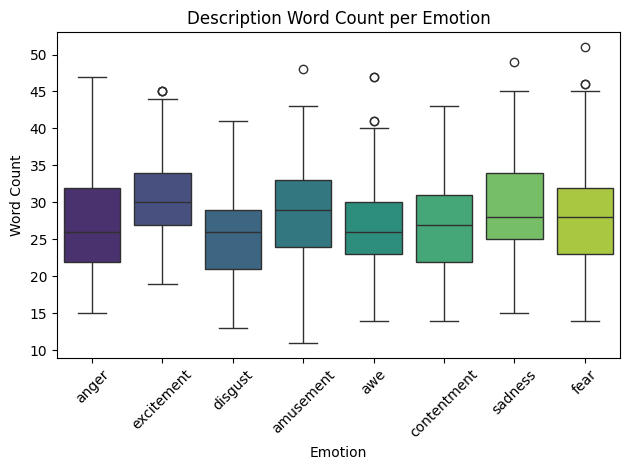

annotations_emotion
excitement     30.416
sadness        29.152
amusement      28.624
fear           28.152
anger          27.512
contentment    27.072
awe            26.728
disgust        25.608
Name: description_word_count, dtype: float64


In [102]:
sns.boxplot(data=df, x='annotations_emotion', y='description_word_count', 
            palette='viridis', hue='annotations_emotion', legend=False)
plt.title('Description Word Count per Emotion')
plt.xlabel('Emotion')
plt.ylabel('Word Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df.groupby('annotations_emotion')['description_word_count'].mean().sort_values(ascending=False))



Description length is largely consistent across emotions (median ~26–30 words), suggesting GPT generates captions of similar length regardless of emotional content. Excitement and sadness trend slightly longer, possibly reflecting more complex or narrative-rich scenes, while disgust and awe tend toward shorter descriptions — but the differences are modest and unlikely to be a meaningful signal for modeling.

### Missing Value Analysis

We examine whether missing values in the visual features are randomly distributed across the dataset or systematically concentrated in specific emotion categories - the latter would suggest the missingness is meaningful rather than noise.

--- Missing Values per Column ---
image_name                         0
description                        0
embedding                          0
viewer_feelings                    0
description_embedding              0
viewer_feelings_embedding          0
annotations_emotion                0
annotations_brightness             1
annotations_colorfulness          24
annotations_facial_expression    888
annotations_object               487
annotations_human_action         886
annotations_scene                788
description_word_count             0
desc_feelings_cosine_sim           0
dtype: int64

--- Missing Values per Emotion ---
                     annotations_brightness  annotations_colorfulness  \
annotations_emotion                                                     
amusement                                 0                         1   
anger                                     0                        10   
awe                                       0                         2 

C:\Users\odis\AppData\Local\Temp\ipykernel_60220\385306808.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_by_emotion = df.groupby('annotations_emotion').apply(lambda x: x.isnull().sum())
C:\Users\odis\AppData\Local\Temp\ipykernel_60220\385306808.py:11: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  missing_rates = df.groupby('annotations_emotion').apply(


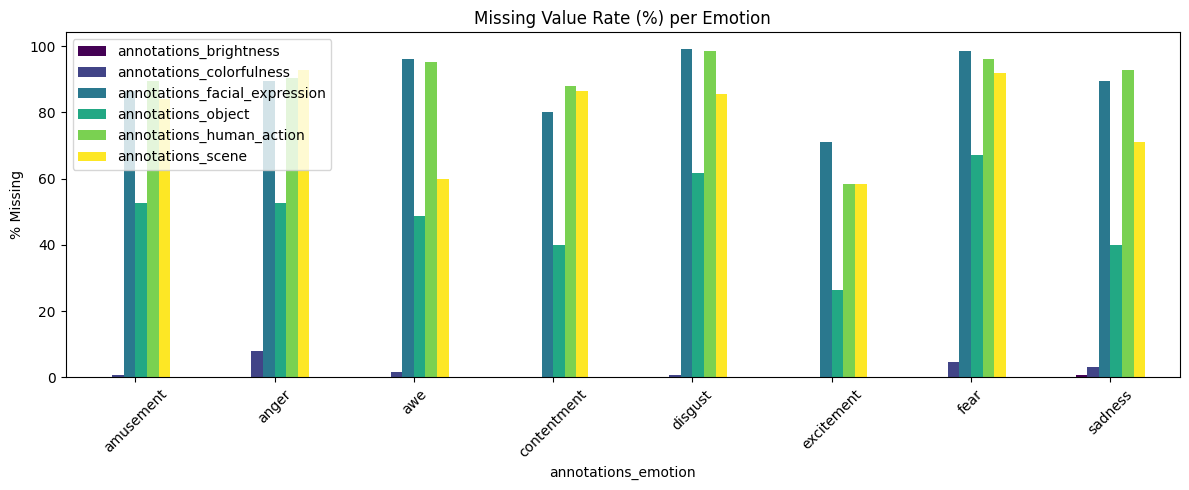

In [75]:
# missing values overview
print("--- Missing Values per Column ---")
print(df.isnull().sum())

# missing values per emotion category
print("\n--- Missing Values per Emotion ---")
missing_by_emotion = df.groupby('annotations_emotion').apply(lambda x: x.isnull().sum())
print(missing_by_emotion[[col for col in df.columns if df[col].isnull().any()]])

# visualize missingness per emotion
missing_rates = df.groupby('annotations_emotion').apply(
    lambda x: x.isnull().mean() * 100
)[[col for col in df.columns if df[col].isnull().any()]]

missing_rates.plot(kind='bar', figsize=(12, 5), colormap='viridis')
plt.title('Missing Value Rate (%) per Emotion')
plt.ylabel('% Missing')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

As we can see from the chart, brightness and colorfulness are nearly complete across all emotions and can be used as-is. The remaining features - facial expression, object, human action, and scene - are massively sparse (40–100% missing), which is expected given that not every image contains a face, object, or identifiable scene. Notably, missingness is not uniformly random: excitement images have substantially lower missing rates, suggesting they more frequently depict people in action, while awe and disgust show near-complete absence of facial expressions, implying these emotions are more scene-driven. We can also see that the features annotations_human_action, annotations_scene and annotations_facial_expression are largely missing.

Let's roll out a small non-representing sample to try and get a feel for the relationship between the annotations and description: 

In [76]:
import random
seed = 42
random.seed(seed)

sparse_features = ['annotations_facial_expression', 'annotations_object', 
                   'annotations_human_action', 'annotations_scene', ]

for feature in sparse_features:
    print(f"\n{'='*60}")
    print(f"FEATURE: {feature}")
    print(f"{'='*60}")
    
    missing_samples = df[df[feature].isna()]['description'].dropna().tolist()
    present_samples = df[df[feature].notna()][['description', feature]].dropna().values.tolist()
    
    if missing_samples:
        sample = random.choice(missing_samples)
        print(f"\n[MISSING] {feature} = NaN")
        print(f"Description: {sample}")
    
    if present_samples:
        desc, val = random.choice(present_samples)
        print(f"\n[PRESENT] {feature} = '{val}'")
        print(f"Description: {desc}")


FEATURE: annotations_facial_expression

[MISSING] annotations_facial_expression = NaN
Description: A band performs on stage, featuring a guitarist with long hair playing a light green guitar, a vocalist in a blue shirt holding a red guitar, and a drummer in the background, with colorful stage lighting enhancing the scene.

[PRESENT] annotations_facial_expression = 'happy'
Description: A woman lies in a bed surrounded by cushions, holding an infant in her arm while a young boy in pajamas hugs her from behind, and a soft light illuminates the cozy room.

FEATURE: annotations_object

[MISSING] annotations_object = NaN
Description: A person in a gray jacket and black leggings stands on a grassy hillside at sunset, next to a wooden information sign, with rolling hills and distant mountains in the background.

[PRESENT] annotations_object = '['Plant']'
Description: A wooden structure is engulfed in large flames billowing smoke into the air, surrounded by a grassy field and a wooden fence.



as we can see, the attributes don't neccessarily reflect the description of the picture and seem quite unreliable (e. g. in the last exampe the scene should be sky rather than NaN etc.)

### Feature Correlation Analysis

We're going to have to perform dimentionality reduction on the embeddings to try and see if we can find any meaningful correlations. However, even now we can see that the Pearson Correlation between brightness and colorfulness is 0.24 which indicates that they're largely independant - good news.

In [77]:
print(f"Pearson correlation between brightness and colorfulness: {df['annotations_brightness'].corr(df['annotations_colorfulness']):.2f}")

Pearson correlation between brightness and colorfulness: 0.24
